## ***"Klasifikasi Hierarkis Dua Tahap Menggunakan IndoBERT untuk Deteksi Distorsi Kognitif pada Teks Bahasa Indonesia"***

### **Nama Anggota:**

### **Anggi Permata Sari**

### **Eugenia Grasela Maia**

### **Sultan Bani Hakim**

### ***Instalasi & Import Library***

In [ ]:
!pip install transformers torch pandas scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### ***Persiapan Dataset & Pembersihan***

In [ ]:
from google.colab import files
import io
import pandas as pd
from sklearn.preprocessing import LabelEncoder

print("Silakan upload file dataset (CSV) kamu:")
uploaded = files.upload()
file_name = next(iter(uploaded))
print(f"\nFile '{file_name}' berhasil diunggah! Memulai ekstraksi dan augmentasi...")

def prepare_datasets(file_content):
    df = pd.read_csv(io.BytesIO(file_content))
    df = df.dropna(subset=['TEXT', 'FIRST ANNOTATOR'])

    df['TEXT'] = df['TEXT'].str.replace('$', '', regex=False)

    teks_tambahan = [
        "Saya merasa sangat bahagia dan bersyukur karena hasil kerja keras saya selama ini terbayar lunas dengan pencapaian yang luar biasa.",
        "Hari ini adalah bukti jerih payah saya. Saya merasa sangat bangga pada diri sendiri atas kesuksesan ini.",
        "Semua kelelahan dan kerja keras saya akhirnya membuahkan hasil yang manis. Saya merasa sangat lega dan antusias menatap masa depan.",
        "Saya sangat senang karena pencapaian saya hari ini membuktikan bahwa dedikasi dan fokus tidak akan mengkhianati hasil.",
        "Meskipun banyak tantangan, saya merasa bersyukur bisa melewatinya. Ini adalah pencapaian yang membuat saya semakin percaya diri.",
        "Saya merasa terharu melihat hasil project saya sukses besar, ini adalah bukti nyata dari kerja keras tim berbulan-bulan.",
        "Perasaan saya sangat luar biasa hari ini, pencapaian akademik saya akhirnya mendapat pengakuan setelah sekian lama berusaha keras.",
        "Kerja keras memang tidak pernah mengkhianati hasil. Saya merasa sangat puas dan bahagia dengan apa yang saya raih hari ini.",
        "Saya sangat bangga pada diri sendiri. Semua pengorbanan, rasa lelah, dan air mata akhirnya berubah menjadi pencapaian yang membahagiakan.",
        "Menjadi juara di kompetisi ini adalah bukti jerih payah saya terbayar. Saya merasa sangat bersyukur dan bersemangat."
    ]

    teks_tambahan = teks_tambahan * 5

    df_sintetis = pd.DataFrame({
        'TEXT': teks_tambahan,
        'FIRST ANNOTATOR': ['No Distortion'] * len(teks_tambahan)
    })

    df = pd.concat([df, df_sintetis], ignore_index=True)
    # =========================================================================

    # Dataset Stage 1 (Binary)
    df_stage1 = df.copy()
    df_stage1['label'] = df_stage1['FIRST ANNOTATOR'].apply(lambda x: 0 if x == 'No Distortion' else 1)

    # Dataset Stage 2 (Multiclass)
    df_stage2 = df[df['FIRST ANNOTATOR'] != 'No Distortion'].copy()

    le = LabelEncoder()
    df_stage2['label'] = le.fit_transform(df_stage2['FIRST ANNOTATOR'])

    return df_stage1, df_stage2, le

df_s1, df_s2, label_encoder = prepare_datasets(uploaded[file_name])
print("Data Stage 1 (Biner) siap. Jumlah baris:", len(df_s1))
print("Data Stage 2 (Multiclass) siap. Jumlah baris:", len(df_s2))

Silakan upload file dataset (CSV) kamu:


Saving COGNITIVE DISTORTION DATASET IN BAHASA INDONESIA COMPLETE.csv to COGNITIVE DISTORTION DATASET IN BAHASA INDONESIA COMPLETE (2).csv

File 'COGNITIVE DISTORTION DATASET IN BAHASA INDONESIA COMPLETE (2).csv' berhasil diunggah! Memulai ekstraksi dan augmentasi...
Data Stage 1 (Biner) siap. Jumlah baris: 5042
Data Stage 2 (Multiclass) siap. Jumlah baris: 2746


### ***Konfigurasi PyTorch Dataset***

In [ ]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

### ***Function Training, Plot Grafik & Matrix***

In [ ]:
def train_and_evaluate(df, num_labels, model_name_to_save, class_names, epochs=20):
    print(f"\n{'='*60}\n[MEMULAI TRAINING] Model: {model_name_to_save} | Jumlah Kelas: {num_labels}\n{'='*60}")

    X_train, X_test, y_train, y_test = train_test_split(
        df['TEXT'].values, df['label'].values, test_size=0.2, random_state=42, stratify=df['label'].values
    )

    tokenizer = AutoTokenizer.from_pretrained('indobenchmark/indobert-base-p1')

    train_dataset = TextDataset(X_train, y_train, tokenizer)
    test_dataset = TextDataset(X_test, y_test, tokenizer)

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
    train_eval_loader = DataLoader(train_dataset, batch_size=16, shuffle=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = AutoModelForSequenceClassification.from_pretrained('indobenchmark/indobert-base-p1', num_labels=num_labels).to(device)
    optimizer = AdamW(model.parameters(), lr=2e-5)

    loss_history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            total_loss += loss.item()

            loss.backward()
            optimizer.step()

        avg_loss = total_loss / len(train_loader)
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1:02d}/{epochs} - Loss: {avg_loss:.4f}")

    def get_predictions(loader):
        model.eval()
        preds_list, real_list = [], []
        with torch.no_grad():
            for batch in loader:
                outputs = model(input_ids=batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device))
                _, preds = torch.max(outputs.logits, dim=1)
                preds_list.extend(preds.cpu().numpy())
                real_list.extend(batch['label'].to(device).cpu().numpy())
        return real_list, preds_list

    print("\n[INFO] Menghitung metrik untuk Confusion Matrix...")
    train_real, train_preds = get_predictions(train_eval_loader)
    test_real, test_preds = get_predictions(test_loader)

    print(f"\n[CLASSIFICATION REPORT - TESTING DATA] {model_name_to_save}")
    print(classification_report(test_real, test_preds, target_names=class_names))

    sns.set_theme(style="whitegrid")

    # Grafik Kurva Loss
    plt.figure(figsize=(10, 4))
    plt.plot(range(1, epochs+1), loss_history, marker='o', linestyle='-', color='#D32F2F', linewidth=2)
    plt.title(f'Training Loss Curve (20 Epochs) - {model_name_to_save}', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss Value', fontsize=12)
    plt.xticks(range(1, epochs+1))
    plt.show()

    # Visualisasi Confusion Matrix
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Matrix Training
    cm_train = confusion_matrix(train_real, train_preds)
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    axes[0].set_title(f'Confusion Matrix - DATA TRAINING\nAccuracy: {accuracy_score(train_real, train_preds)*100:.2f}%', fontweight='bold')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')
    axes[0].tick_params(axis='x', rotation=45)

    # Matrix Testing
    cm_test = confusion_matrix(test_real, test_preds)
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    axes[1].set_title(f'Confusion Matrix - DATA TESTING\nAccuracy: {accuracy_score(test_real, test_preds)*100:.2f}%', fontweight='bold')
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    model.save_pretrained(f"./{model_name_to_save}")
    tokenizer.save_pretrained(f"./{model_name_to_save}")
    print(f"Model berhasil tersimpan di ./{model_name_to_save}\n")

### ***Class Distribution***

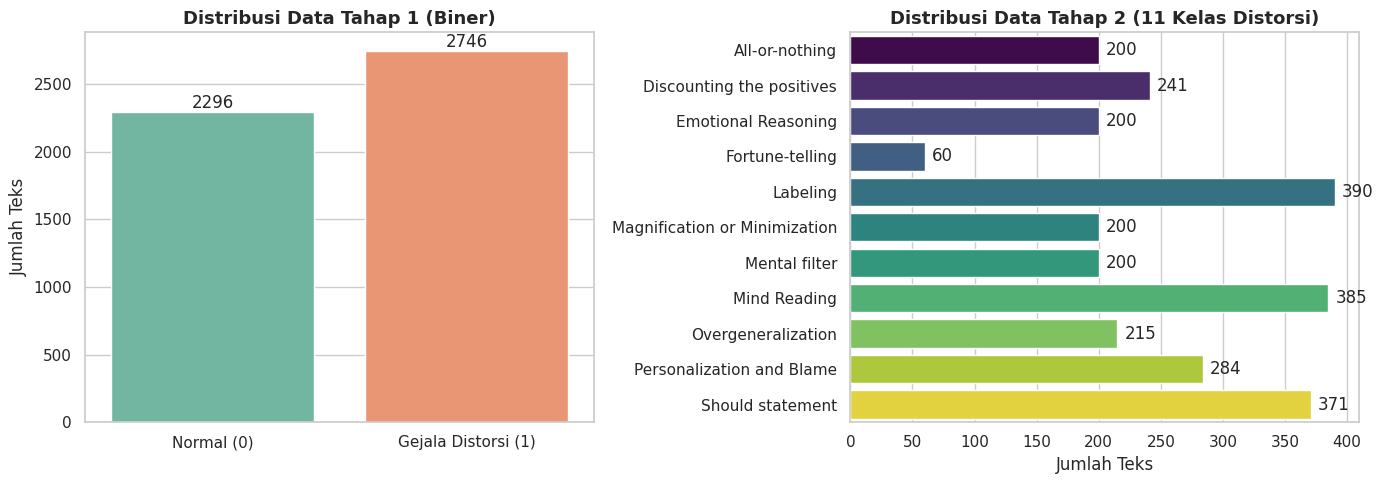

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 5))
sns.set_theme(style="whitegrid")

# Plot Stage 1 (Biner)
plt.subplot(1, 2, 1)
ax1 = sns.countplot(x='label', data=df_s1, palette='Set2', hue='label', legend=False)
plt.title('Distribusi Data Tahap 1 (Biner)', fontweight='bold', fontsize=13)
plt.xticks([0, 1], ['Normal (0)', 'Gejala Distorsi (1)'])
plt.ylabel('Jumlah Teks')
plt.xlabel('')
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

# Plot Stage 2 (Multiclass)
plt.subplot(1, 2, 2)
ax2 = sns.countplot(y='label', data=df_s2, palette='viridis', hue='label', legend=False)
plt.title('Distribusi Data Tahap 2 (11 Kelas Distorsi)', fontweight='bold', fontsize=13)
plt.yticks(range(11), label_encoder.classes_)
plt.xlabel('Jumlah Teks')
plt.ylabel('')
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

### ***Training***


[MEMULAI TRAINING] Model: indobert_stage1_binary | Jumlah Kelas: 2


[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 01/7 - Loss: 0.5943
Epoch 02/7 - Loss: 0.4269
Epoch 03/7 - Loss: 0.2664
Epoch 04/7 - Loss: 0.1570
Epoch 05/7 - Loss: 0.0694
Epoch 06/7 - Loss: 0.0359
Epoch 07/7 - Loss: 0.0353

[INFO] Menghitung metrik untuk Confusion Matrix...

[CLASSIFICATION REPORT - TESTING DATA] indobert_stage1_binary
                     precision    recall  f1-score   support

         Normal (0)       0.79      0.63      0.70       459
Gejala Distorsi (1)       0.74      0.86      0.79       550

           accuracy                           0.76      1009
          macro avg       0.76      0.75      0.75      1009
       weighted avg       0.76      0.76      0.75      1009



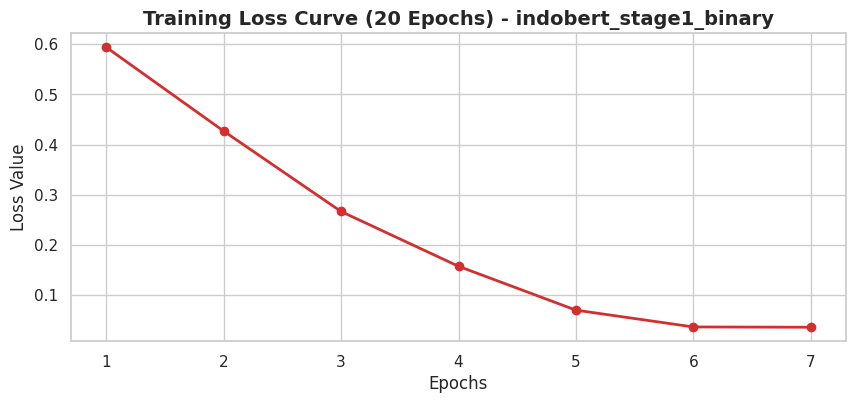

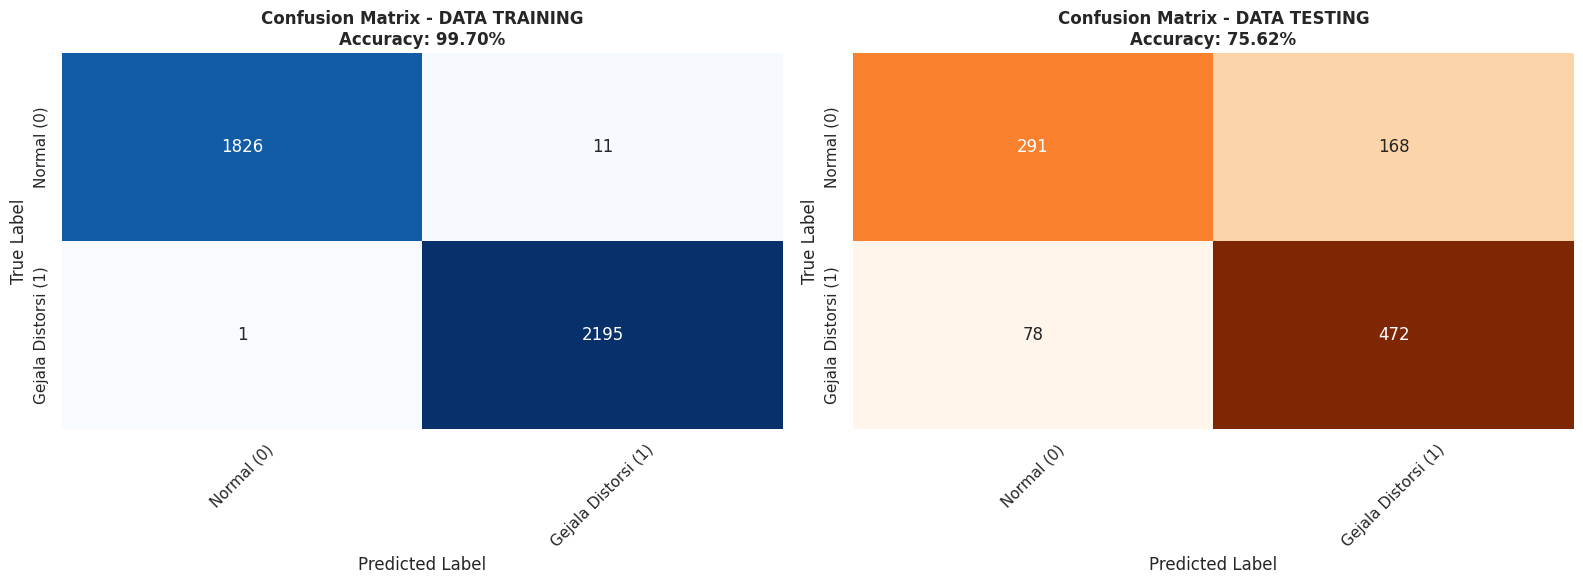

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model berhasil tersimpan di ./indobert_stage1_binary


[MEMULAI TRAINING] Model: indobert_stage2_multiclass | Jumlah Kelas: 11


[transformers] You passed `num_labels=11` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 01/7 - Loss: 1.4902
Epoch 02/7 - Loss: 0.6265
Epoch 03/7 - Loss: 0.3414
Epoch 04/7 - Loss: 0.1663
Epoch 05/7 - Loss: 0.0703
Epoch 06/7 - Loss: 0.0309
Epoch 07/7 - Loss: 0.0244

[INFO] Menghitung metrik untuk Confusion Matrix...

[CLASSIFICATION REPORT - TESTING DATA] indobert_stage2_multiclass
                               precision    recall  f1-score   support

               All-or-nothing       0.79      0.78      0.78        40
    Discounting the positives       0.81      0.96      0.88        48
          Emotional Reasoning       0.76      0.80      0.78        40
              Fortune-telling       0.31      0.33      0.32        12
                     Labeling       0.89      0.63      0.74        78
Magnification or Minimization       0.88      0.70      0.78        40
                Mental filter       0.86      0.80      0.83        40
                 Mind Reading       0.74      0.82      0.78        77
           Overgeneralization       0.68      0.63      0.6

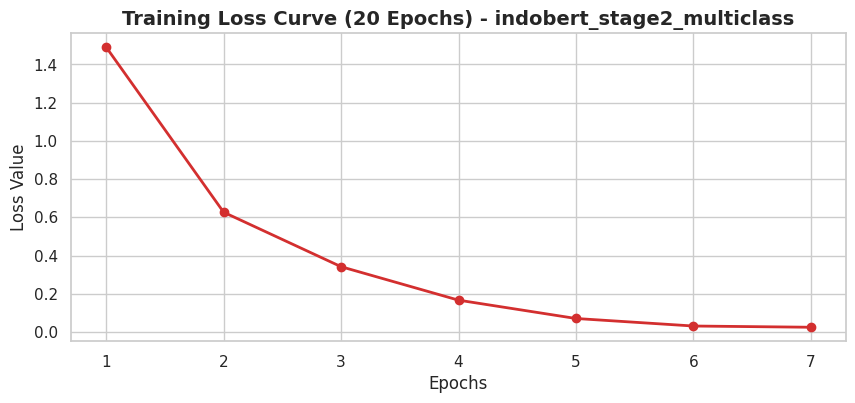

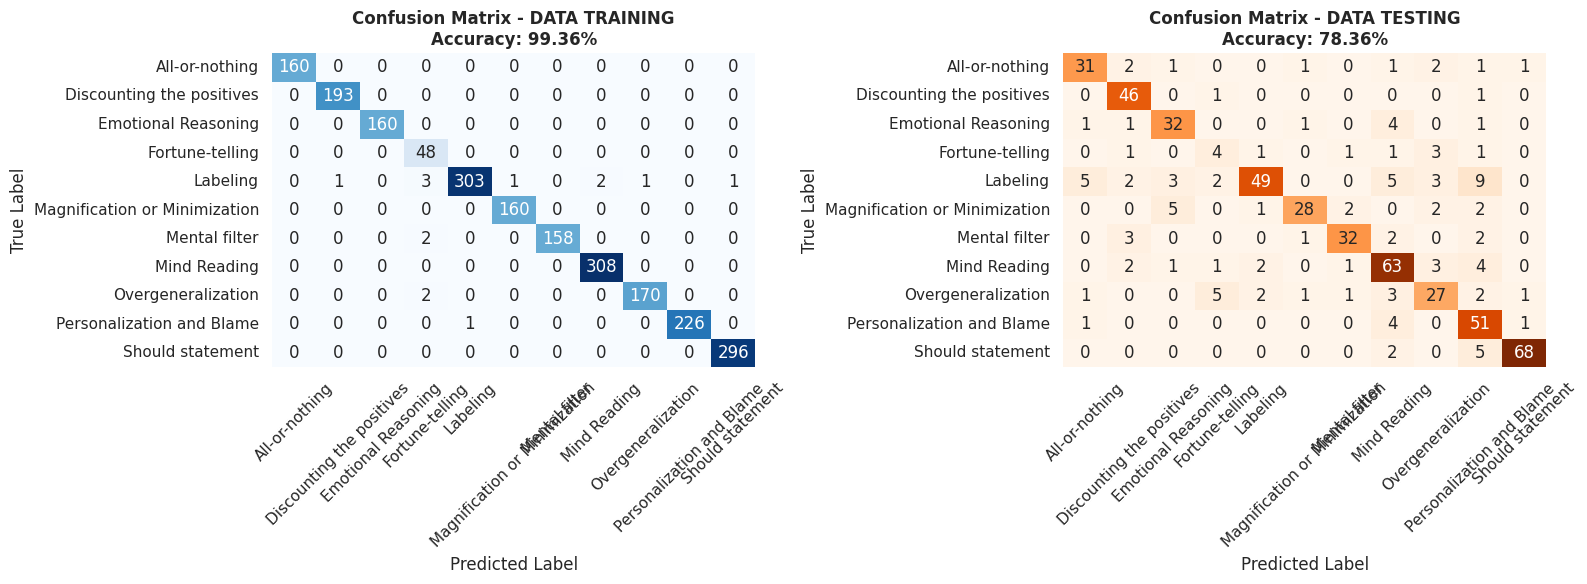

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model berhasil tersimpan di ./indobert_stage2_multiclass



In [ ]:
biner_classes = ['Normal (0)', 'Gejala Distorsi (1)']
multiclass_classes = label_encoder.classes_

# Model 1 (Biner)
train_and_evaluate(df_s1, num_labels=2, model_name_to_save="indobert_stage1_binary", class_names=biner_classes, epochs=7)

# Model 2 (Multiclass)
train_and_evaluate(df_s2, num_labels=11, model_name_to_save="indobert_stage2_multiclass", class_names=multiclass_classes, epochs=7)

### ***Grafik F1-Score per Kelas***

Melakukan inferensi cepat untuk memuat grafik F1-Score (Hanya hitungan detik)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

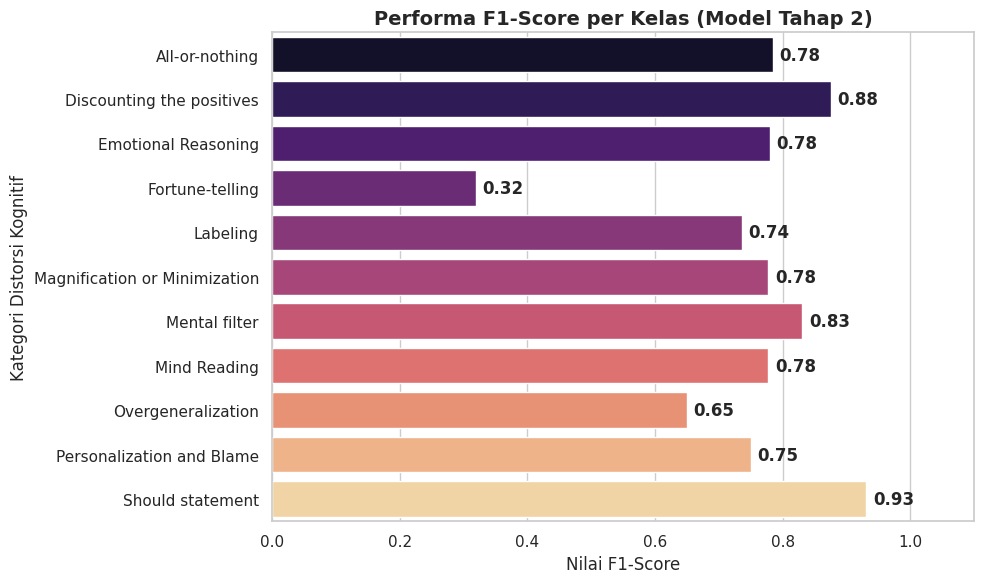

In [ ]:
from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import torch
import seaborn as sns
import matplotlib.pyplot as plt

print("Melakukan inferensi cepat untuk memuat grafik F1-Score (Hanya hitungan detik)...")

_, X_test_s2, _, y_test_s2 = train_test_split(
    df_s2['TEXT'].values, df_s2['label'].values, test_size=0.2, random_state=42, stratify=df_s2['label'].values
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer_eval = AutoTokenizer.from_pretrained("./indobert_stage2_multiclass")
model_eval = AutoModelForSequenceClassification.from_pretrained("./indobert_stage2_multiclass").to(device)
model_eval.eval()

test_dataset_s2 = TextDataset(X_test_s2, y_test_s2, tokenizer_eval)
test_loader_s2 = DataLoader(test_dataset_s2, batch_size=16, shuffle=False)

eval_preds, eval_real = [], []
with torch.no_grad():
    for batch in test_loader_s2:
        outputs = model_eval(input_ids=batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device))
        _, preds = torch.max(outputs.logits, dim=1)
        eval_preds.extend(preds.cpu().numpy())
        eval_real.extend(batch['label'].to(device).cpu().numpy())

_, _, f1_scores, _ = precision_recall_fscore_support(eval_real, eval_preds, average=None)
class_names = label_encoder.classes_

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=f1_scores, y=class_names, palette='magma', hue=class_names, legend=False)
plt.title('Performa F1-Score per Kelas (Model Tahap 2)', fontweight='bold', fontsize=14)
plt.xlabel('Nilai F1-Score', fontsize=12)
plt.ylabel('Kategori Distorsi Kognitif', fontsize=12)
plt.xlim(0, 1.1)

for index, value in enumerate(f1_scores):
    plt.text(value + 0.01, index, f'{value:.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

### ***Arsitektur Sistem***

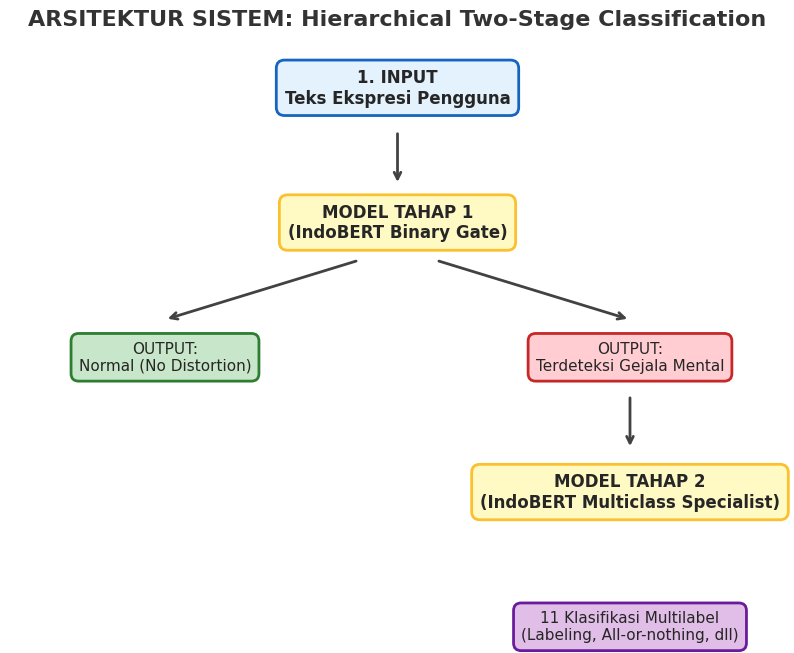

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_architecture():
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.axis('off')

    box_style = "round,pad=0.5"

    # Draw Nodes
    ax.text(0.5, 0.9, "1. INPUT\nTeks Ekspresi Pengguna", ha="center", va="center", size=12, fontweight='bold', bbox=dict(boxstyle=box_style, fc="#E3F2FD", ec="#1565C0", lw=2))

    ax.text(0.5, 0.65, "MODEL TAHAP 1\n(IndoBERT Binary Gate)", ha="center", va="center", size=12, fontweight='bold', bbox=dict(boxstyle=box_style, fc="#FFF9C4", ec="#FBC02D", lw=2))

    ax.text(0.2, 0.4, "OUTPUT:\nNormal (No Distortion)", ha="center", va="center", size=11, bbox=dict(boxstyle=box_style, fc="#C8E6C9", ec="#2E7D32", lw=2))
    ax.text(0.8, 0.4, "OUTPUT:\nTerdeteksi Gejala Mental", ha="center", va="center", size=11, bbox=dict(boxstyle=box_style, fc="#FFCDD2", ec="#C62828", lw=2))

    ax.text(0.8, 0.15, "MODEL TAHAP 2\n(IndoBERT Multiclass Specialist)", ha="center", va="center", size=12, fontweight='bold', bbox=dict(boxstyle=box_style, fc="#FFF9C4", ec="#FBC02D", lw=2))

    ax.text(0.8, -0.1, "11 Klasifikasi Multilabel\n(Labeling, All-or-nothing, dll)", ha="center", va="center", size=11, bbox=dict(boxstyle=box_style, fc="#E1BEE7", ec="#6A1B9A", lw=2))

    # Draw Arrows
    ax.annotate("", xy=(0.5, 0.72), xytext=(0.5, 0.82), arrowprops=dict(arrowstyle="->", lw=2, color="#424242"))
    ax.annotate("", xy=(0.2, 0.47), xytext=(0.45, 0.58), arrowprops=dict(arrowstyle="->", lw=2, color="#424242"))
    ax.annotate("", xy=(0.8, 0.47), xytext=(0.55, 0.58), arrowprops=dict(arrowstyle="->", lw=2, color="#424242"))
    ax.annotate("", xy=(0.8, 0.23), xytext=(0.8, 0.33), arrowprops=dict(arrowstyle="->", lw=2, color="#424242"))
    ax.annotate("", xy=(0.8, -0.02), xytext=(0.8, 0.07), arrowprops=dict(arrowstyle="->", lw=2, color="#424242"))

    plt.title("ARSITEKTUR SISTEM: Hierarchical Two-Stage Classification", fontsize=16, fontweight='bold', color="#333333")
    plt.show()

draw_architecture()

### ***Inferensi & Kamus***

In [ ]:
print("Mengunci model ke memori GPU untuk pengujian...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer_infer = AutoTokenizer.from_pretrained("./indobert_stage1_binary")
model_stage1_infer = AutoModelForSequenceClassification.from_pretrained("./indobert_stage1_binary").to(device)
model_stage2_infer = AutoModelForSequenceClassification.from_pretrained("./indobert_stage2_multiclass").to(device)

model_stage1_infer.eval()
model_stage2_infer.eval()

kamus_distorsi = {
    "All-or-nothing": "Melihat segala sesuatu secara ekstrem (sempurna atau gagal total).",
    "Discounting the positives": "Menolak hal positif dan bersikeras bahwa itu hanya kebetulan.",
    "Emotional Reasoning": "Menganggap perasaan negatif sebagai kebenaran mutlak.",
    "Fortune-telling": "Meramal masa depan secara buruk tanpa bukti.",
    "Labeling": "Menempelkan cap negatif ekstrem pada diri sendiri akibat satu kesalahan.",
    "Magnification or Minimization": "Membesar-besarkan masalah atau mengecilkan keberhasilan.",
    "Mental filter": "Fokus hanya pada detail negatif dan mengabaikan sisi positif.",
    "Mind Reading": "Menyimpulkan orang lain berpikiran negatif tentang dirinya tanpa bukti.",
    "Overgeneralization": "Menarik kesimpulan negatif secara luas dari satu kegagalan.",
    "Personalization and Blame": "Menyalahkan diri sendiri atas peristiwa di luar kendali.",
    "Should statement": "Menuntut diri dengan kata 'harus/seharusnya' secara tidak realistis."
}

def predict_mental_health_clean(text, label_encoder, sensitivity_threshold=0.35):
    inputs = tokenizer_infer(text, return_tensors="pt", truncation=True, max_length=128, padding='max_length').to(device)

    with torch.no_grad():
        outputs_1 = model_stage1_infer(**inputs)
        prob_1 = torch.softmax(outputs_1.logits, dim=1).cpu().numpy()[0]

    print(f"\n[ANALISIS GERBANG 1] Keyakinan Normal: {prob_1[0]*100:.2f}% | Gejala: {prob_1[1]*100:.2f}%")

    if prob_1[1] < sensitivity_threshold:
        return "KESIMPULAN: Teks Normal ✅\n"
    else:
        with torch.no_grad():
            outputs_2 = model_stage2_infer(**inputs)
            prob_2 = torch.softmax(outputs_2.logits, dim=1).cpu().numpy()[0]
            pred_2 = np.argmax(prob_2)

        jenis = label_encoder.inverse_transform([pred_2])[0]
        arti = kamus_distorsi.get(jenis, "-")

        return f"KESIMPULAN: TERDETEKSI GEJALA (DISTORSI KOGNITIF) ⚠️\n-> Jenis Prediksi : {jenis} ({prob_2[pred_2]*100:.2f}%)\n-> Definisi       : {arti}\n"

Mengunci model ke memori GPU untuk pengujian...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

### ***Testing***

In [ ]:
teks_test = "saya seperti orang yang tidak bisa apa apa karena tidak bisa metematika, saya orang yang sangat bodoh dan tolol"
print(predict_mental_health_clean(teks_test, label_encoder))


[ANALISIS GERBANG 1] Keyakinan Normal: 17.98% | Gejala: 82.02%
KESIMPULAN: TERDETEKSI GEJALA (DISTORSI KOGNITIF) ⚠️
-> Jenis Prediksi : Labeling (99.44%)
-> Definisi       : Menempelkan cap negatif ekstrem pada diri sendiri akibat satu kesalahan.

